In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from sympy.codegen.rewriting import optimize
from scipy import optimize
from table1 import table

In [3]:
k = 2
n = 3
m = 1
count_points = 11
x_sym = sp.symbols('x')


In [4]:
from table1 import table

SELECTED_ROW = 0


a = float(table[SELECTED_ROW]['a'])
b = float(table[SELECTED_ROW]['b'])
f_expr = table[SELECTED_ROW]['f_expr']

In [5]:
# ------------------------
# Часть 1: определяем f
# ------------------------
f = sp.lambdify(x_sym, f_expr, modules=['numpy'])

x_points = np.linspace(a, b, count_points)
y_points = f(x_points)

x_fit = np.linspace(a, b, 500)
y_fit = f(x_fit)
x_star = x_points[m]



In [6]:
# f_prime_expr = sp.diff(f_expr, x_sym)
# f_prime_expr2 = sp.diff(f_prime_expr, x_sym)
def derivative(f_expr_in, n_step):

    current_derivative = f_expr_in

    for _ in range(n_step):
        current_derivative = sp.diff(current_derivative, x_sym)

    return current_derivative


In [7]:
# ------------------------
# Часть 2 (сдана) (сделана): Лагранж 3 (сделана)-го порядка
# ------------------------
x0_sym = sp.Rational(str(x_points[0]))
x1_sym = sp.Rational(str(x_points[1])) # Это x_star так как m = 1
x2_sym = sp.Rational(str(x_points[2]))
x3_sym = sp.Rational(str(x_points[3]))

# Значения функции в узлах
y0_sym = f_expr.subs(x_sym, x0_sym)
y1_sym = f_expr.subs(x_sym, x1_sym)
y2_sym = f_expr.subs(x_sym, x2_sym)
y3_sym = f_expr.subs(x_sym, x3_sym)

In [8]:
# Базисные полиномы l_i(x)
l0 = ( (x_sym - x1_sym) * (x_sym - x2_sym) * (x_sym - x3_sym) ) / \
     ( (x0_sym - x1_sym) * (x0_sym - x2_sym) * (x0_sym - x3_sym) )

l1 = ( (x_sym - x0_sym) * (x_sym - x2_sym) * (x_sym - x3_sym) ) / \
     ( (x1_sym - x0_sym) * (x1_sym - x2_sym) * (x1_sym - x3_sym) )

l2 = ( (x_sym - x0_sym) * (x_sym - x1_sym) * (x_sym - x3_sym) ) / \
     ( (x2_sym - x0_sym) * (x2_sym - x1_sym) * (x2_sym - x3_sym) )

l3 = ( (x_sym - x0_sym) * (x_sym - x1_sym) * (x_sym - x2_sym) ) / \
     ( (x3_sym - x0_sym) * (x3_sym - x1_sym) * (x3_sym - x2_sym) )

# Собираем многочлен L3(x)
L3_expr = y0_sym * l0 + y1_sym * l1 + y2_sym * l2 + y3_sym * l3

In [9]:
f_prime2_expr = derivative(f_expr, 1)
L3_prime2_expr = derivative(L3_expr, 1)
L3_prime2_at_x_star = L3_prime2_expr.subs(x_sym, x_star)
f_prime2_at_x_star = f_prime2_expr.subs(x_sym, x_star)

In [10]:
print(f_prime2_expr)
print(L3_prime2_expr)


2*x + 1/x
4000*(x - 11/20)*(x - 1/2)*(log(9/20) + 81/400) - 4000*(x - 11/20)*(x - 1/2)*(log(2/5) + 4/25)/3 - 4000*(x - 11/20)*(x - 9/20)*(log(2/5) + 4/25)/3 - 4000*(1/4 - log(2))*(x - 11/20)*(x - 9/20) + 4000*(x - 11/20)*(x - 2/5)*(log(9/20) + 81/400) - 4000*(1/4 - log(2))*(x - 11/20)*(x - 2/5) + 4000*(x - 1/2)*(x - 9/20)*(log(11/20) + 121/400)/3 - 4000*(x - 1/2)*(x - 9/20)*(log(2/5) + 4/25)/3 + 4000*(x - 1/2)*(x - 2/5)*(log(9/20) + 81/400) + 4000*(x - 1/2)*(x - 2/5)*(log(11/20) + 121/400)/3 + 4000*(x - 9/20)*(x - 2/5)*(log(11/20) + 121/400)/3 - 4000*(1/4 - log(2))*(x - 9/20)*(x - 2/5)


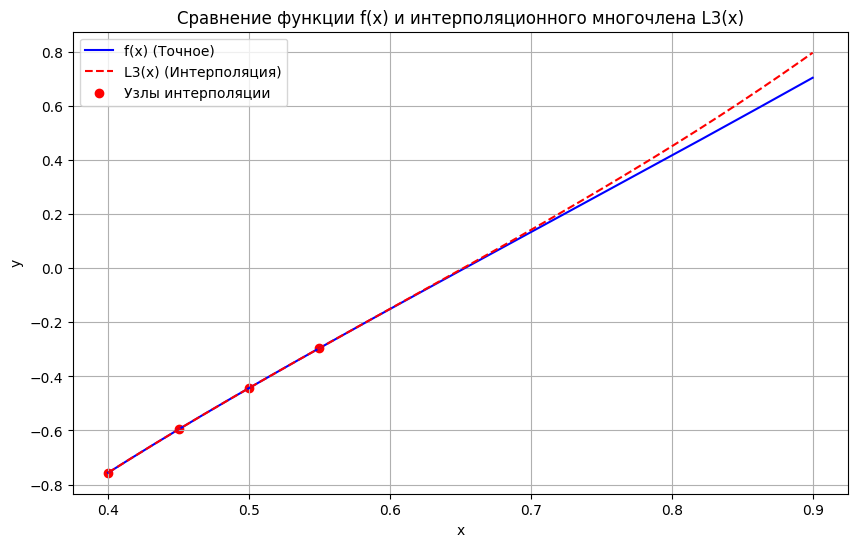

In [15]:
# Lambda-функции для построения графиков
f_lambda = sp.lambdify(x_sym, f_expr, modules=['numpy'])
L3_lambda = sp.lambdify(x_sym, L3_expr, modules=['numpy'])

x_fit_fine = np.linspace(a, b, 500)
y_fit_f = f_lambda(x_fit_fine)
y_fit_L3 = L3_lambda(x_fit_fine)

plt.figure(figsize=(10, 6))
plt.plot(x_fit_fine, y_fit_f, label='f(x) (Точное)', color='blue')
plt.plot(x_fit_fine, y_fit_L3, label='L3(x) (Интерполяция)', linestyle='--', color='red')
plt.scatter(x_points[:4], y_points[:4], color='red', marker='o', label='Узлы интерполяции')
plt.title('Сравнение функции f(x) и интерполяционного многочлена L3(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
omega_4_expr = (x_sym - x0_sym) * (x_sym - x1_sym) * (x_sym - x2_sym) * (x_sym - x3_sym)


In [13]:
import math


n_plus_1 = n + 1 # 4
f_n_plus_1_expr = derivative(f_expr, n_plus_1)

# Используем sp.Abs() для модуля и численный поиск (т.к. sp.minimum/maximum могут быть неточны для сложных ф-ций)
f_n_plus_1_lambda = sp.lambdify(x_sym, sp.Abs(f_n_plus_1_expr), modules=['numpy'])
# Используем границы узлов [x0, x3]
a_bound = x_points[0]
b_bound = x_points[3]


Max_abs_f_n_plus_1 = max(f_n_plus_1_lambda(a_bound), f_n_plus_1_lambda(b_bound))

omega_n_plus_1_expr = (x_sym - x0_sym) * (x_sym - x1_sym) * (x_sym - x2_sym) * (x_sym - x3_sym)

omega_n_plus_1_prime_k_expr = derivative(omega_n_plus_1_expr, k)

# 1.5. Значение omega_4''(x_m) в точке x_star (x1)
omega_val_at_xm = float(omega_n_plus_1_prime_k_expr.subs(x_sym, x_star))



M = Max_abs_f_n_plus_1 / math.factorial(n_plus_1)

R_nk_bound = M * np.abs(omega_val_at_xm)

# Теоретические границы ошибки R_{3 (сделана),2 (сдана) (сделана)}
R_32_min_bound = -R_nk_bound
R_32_max_bound = R_nk_bound



L3_prime2_at_x_star_num = float(L3_prime2_at_x_star)
f_prime2_at_x_star_num = float(f_prime2_at_x_star)

R_32_actual_error = L3_prime2_at_x_star_num - f_prime2_at_x_star_num

print(f"Фактическая ошибка R_3,2(x1): {R_32_actual_error:.10e}")

if R_32_min_bound <= R_32_actual_error <= R_32_max_bound:
    print("Выполняется")
else:
    print("НЕ выполняется")

Фактическая ошибка R_3,2(x1): 1.3060104364e-03
Выполняется
